SVM

SVM + PCA

In [5]:
import numpy as np

# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# PCA Features
X_train_pca = np.load("X_train_pca.npy")
X_val_pca   = np.load("X_val_pca.npy")
X_test_pca  = np.load("X_test_pca.npy")


Baseline 

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_baseline = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_baseline.fit(X_train_pca, y_train)

val_pred  = svm_baseline.predict(X_val_pca)
test_pred = svm_baseline.predict(X_test_pca)

print("Baseline Validation Acc:", accuracy_score(y_val, val_pred))
print("Baseline Test Acc      :", accuracy_score(y_test, test_pred))


Baseline Validation Acc: 0.9452054794520548
Baseline Test Acc      : 0.8581081081081081


Parameter Tuning

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
])


In [ ]:
param_grid = {
    "svm__C": [0.5, 1, 2, 3, 5],
    "svm__gamma": ["scale", "auto", 0.01, 0.001]
}


In [11]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

In [12]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    svm_pipeline,
    param_grid,
    scoring="accuracy",
    cv= cv_strategy,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_pca, y_train)


Fitting 7 folds for each of 20 candidates, totalling 140 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svm__C': [0.5, 1, ...], 'svm__gamma': ['scale', 'auto', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [13]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_svm_pca = grid.best_estimator_


Best Params: {'svm__C': 2, 'svm__gamma': 0.001}
Best CV Score: 0.8468335787923416


In [14]:
val_acc  = best_svm_pca.score(X_val_pca, y_val)
test_acc = best_svm_pca.score(X_test_pca, y_test)

print("\nTuned SVM + PCA Validation Accuracy:", val_acc)
print("Tuned SVM + PCA Test Accuracy:", test_acc)



Tuned SVM + PCA Validation Accuracy: 0.9246575342465754
Tuned SVM + PCA Test Accuracy: 0.7905405405405406


In [15]:
from sklearn.metrics import classification_report

test_pred = svm_baseline.predict(X_test_pca)

print(classification_report(y_test, test_pred))


              precision    recall  f1-score   support

           0       0.91      0.86      0.89        36
           1       0.85      0.89      0.87        37
           2       0.76      0.70      0.73        37
           3       0.90      0.97      0.94        38

    accuracy                           0.86       148
   macro avg       0.86      0.86      0.86       148
weighted avg       0.86      0.86      0.86       148



c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-package

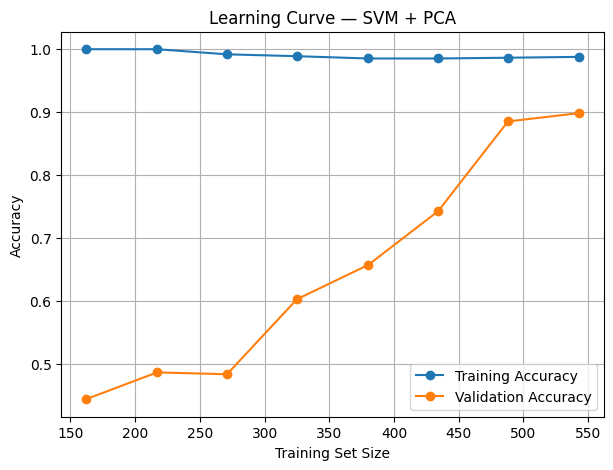

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    svm_baseline,   
    X_train_pca,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — SVM + PCA")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

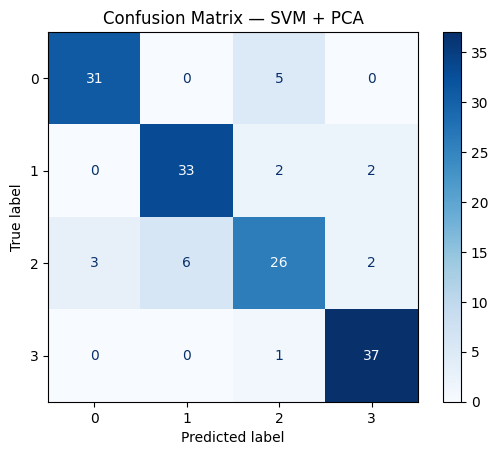

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = svm_baseline.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — SVM + PCA")
plt.show()

In [ ]:
import joblib

joblib.dump(svm_baseline, "models/svm_pca_model.pkl")
print("SVM saved.")

SVM saved.


SVM + MI

In [26]:
import numpy as np

# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# PCA Features
X_train_mi = np.load("X_train_mi.npy")
X_val_mi   = np.load("X_val_mi.npy")
X_test_mi  = np.load("X_test_mi.npy")

Baseline

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_baseline_mi = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_baseline_mi.fit(X_train_mi, y_train)

val_pred  = svm_baseline_mi.predict(X_val_mi)
test_pred = svm_baseline_mi.predict(X_test_mi)

print("Baseline SVM + MI Validation Acc:", accuracy_score(y_val, val_pred))
print("Baseline SVM + MI Test Acc      :", accuracy_score(y_test, test_pred))


Baseline SVM + MI Validation Acc: 0.9246575342465754
Baseline SVM + MI Test Acc      : 0.8445945945945946


Parameter Tuning

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_pipeline_mi = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
])


In [35]:
param_grid = {
    "svm__C": [0.5, 1, 2, 3, 4, 5],
    "svm__gamma": ["scale", 0.05, 0.01, 0.005, 0.001]
}


In [36]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

In [37]:
from sklearn.model_selection import GridSearchCV

grid_mi = GridSearchCV(
    svm_pipeline_mi,
    param_grid,
    scoring="accuracy",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)

grid_mi.fit(X_train_mi, y_train)


Fitting 7 folds for each of 30 candidates, totalling 210 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svm__C': [0.5, 1, ...], 'svm__gamma': ['scale', 0.05, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [38]:
print("Best Params:", grid_mi.best_params_)
print("Best CV Score:", grid_mi.best_score_)

best_svm_mi = grid_mi.best_estimator_


Best Params: {'svm__C': 2, 'svm__gamma': 'scale'}
Best CV Score: 0.9072164948453609


In [39]:
val_acc  = best_svm_mi.score(X_val_mi, y_val)
test_acc = best_svm_mi.score(X_test_mi, y_test)

print("\nTuned SVM + MI Validation Accuracy:", val_acc)
print("Tuned SVM + MI Test Accuracy:", test_acc)



Tuned SVM + MI Validation Accuracy: 0.952054794520548
Tuned SVM + MI Test Accuracy: 0.8513513513513513


In [40]:
from sklearn.metrics import classification_report

test_pred = best_svm_mi.predict(X_test_mi)

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.84      0.86      0.85        37
           2       0.74      0.68      0.70        37
           3       0.92      0.95      0.94        38

    accuracy                           0.85       148
   macro avg       0.85      0.85      0.85       148
weighted avg       0.85      0.85      0.85       148



c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-package

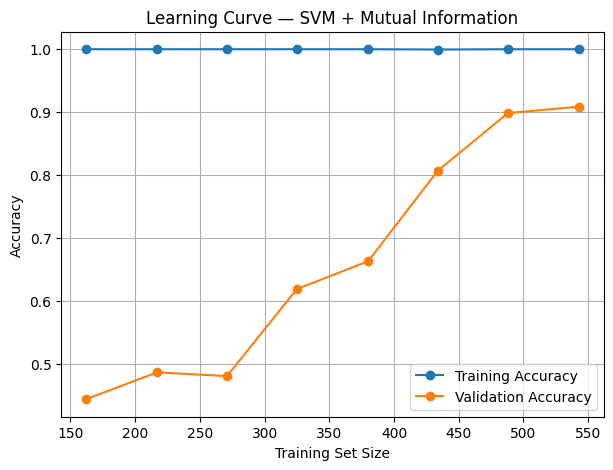

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    best_svm_mi,
    X_train_mi,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — SVM + Mutual Information")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

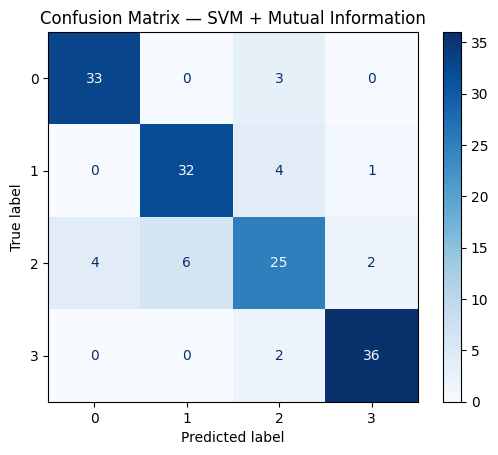

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = best_svm_mi.predict(X_test_mi)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — SVM + Mutual Information")
plt.show()

SVM + Boruta

In [43]:
import numpy as np

# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# PCA Features
X_train_boruta = np.load("X_train_boruta.npy")
X_val_boruta   = np.load("X_val_boruta.npy")
X_test_boruta  = np.load("X_test_boruta.npy")

Baseline

In [44]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_baseline_boruta = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_baseline_boruta.fit(X_train_boruta, y_train)

val_pred  = svm_baseline_boruta.predict(X_val_boruta)
test_pred = svm_baseline_boruta.predict(X_test_boruta)

print("Baseline SVM + Boruta Validation Acc:", accuracy_score(y_val, val_pred))
print("Baseline SVM + Boruta Test Acc      :", accuracy_score(y_test, test_pred))

Baseline SVM + Boruta Validation Acc: 0.9383561643835616
Baseline SVM + Boruta Test Acc      : 0.831081081081081


Parameter Tuning

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_pipeline_boruta = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
])

In [52]:
param_grid = {
    "svm__C": [0.5, 1, 2, 3, 5, 7],
    "svm__gamma": ["scale", 0.01, 0.005, 0.001, 0.0005]
}

In [53]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

In [54]:
from sklearn.model_selection import GridSearchCV

grid_boruta = GridSearchCV(
    svm_pipeline_boruta,
    param_grid,
    scoring="accuracy",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)

grid_boruta.fit(X_train_boruta, y_train)

Fitting 7 folds for each of 30 candidates, totalling 210 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svm__C': [0.5, 1, ...], 'svm__gamma': ['scale', 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [55]:
print("Best Params:", grid_boruta.best_params_)
print("Best CV Score:", grid_boruta.best_score_)

best_svm_boruta = grid_boruta.best_estimator_

Best Params: {'svm__C': 2, 'svm__gamma': 0.005}
Best CV Score: 0.9086892488954346


In [56]:
val_acc  = best_svm_boruta.score(X_val_boruta, y_val)
test_acc = best_svm_boruta.score(X_test_boruta, y_test)

print("\nTuned SVM + Boruta Validation Accuracy:", val_acc)
print("Tuned SVM + Boruta Test Accuracy:", test_acc)


Tuned SVM + Boruta Validation Accuracy: 0.952054794520548
Tuned SVM + Boruta Test Accuracy: 0.831081081081081


In [57]:
from sklearn.metrics import classification_report

test_pred = svm_baseline_boruta.predict(X_test_boruta)

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84        36
           1       0.83      0.92      0.87        37
           2       0.71      0.65      0.68        37
           3       0.90      0.95      0.92        38

    accuracy                           0.83       148
   macro avg       0.83      0.83      0.83       148
weighted avg       0.83      0.83      0.83       148



c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
14 fits failed out of a total of 70.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chanu\OneDrive - Informatics Institute

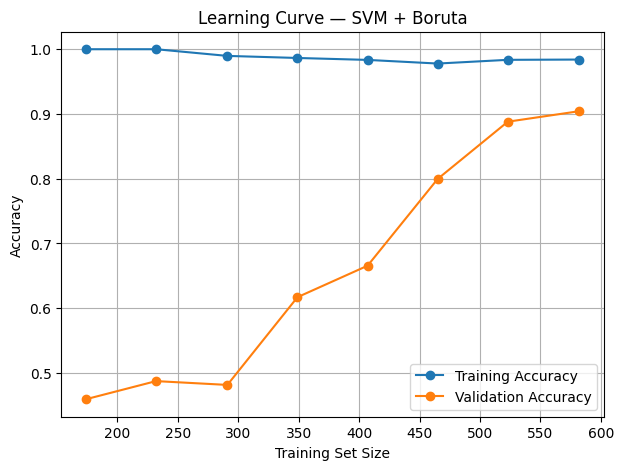

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    svm_baseline_boruta, 
    X_train_boruta,
    y_train,
    cv=7,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — SVM + Boruta")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

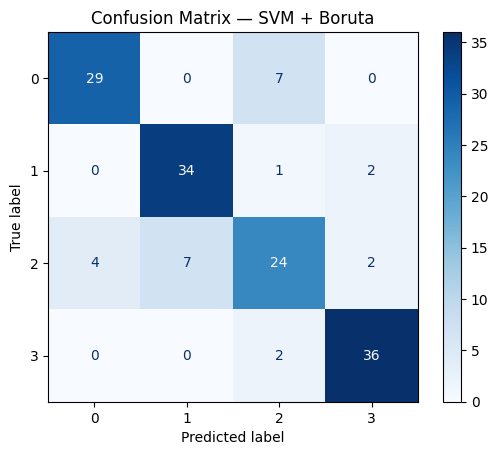

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = svm_baseline_boruta.predict(X_test_boruta)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — SVM + Boruta")
plt.show()